# **Cervical Cancer**

Cervical cancer remains one of the leading causes of cancer-related deaths among women worldwide. Early detection and preventive behavioral assessment can significantly reduce the risk and mortality rate. However, identifying individuals at high risk based on behavioral, social, and psychological factors is challenging using traditional screening methods alone.

This project aims to develop a machine learning classification model to predict the likelihood of cervical cancer (ca_cervix) using behavioral, attitudinal, social support, and empowerment-related factors. By analyzing features such as sexual risk behavior, personal hygiene, perception of vulnerability, motivation strength, and social support indicators, the model will assist in identifying high-risk individuals for early intervention and awareness programs.

## **load and inspect the data**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Dataset/cervical_cancer_dataset.csv")
df

,behavior_sexualRisk,behavior_eating,behavior_personalHygine,intention_aggregation,intention_commitment,attitude_consistency,attitude_spontaneity,norm_significantPerson,norm_fulfillment,perception_vulnerability,perception_severity,motivation_strength,motivation_willingness,socialSupport_emotionality,socialSupport_appreciation,socialSupport_instrumental,empowerment_knowledge,empowerment_abilities,empowerment_desires,ca_cervix
0,14,8,1,9,7,13,1,10,12,4,6,7,0,5,0,1,15,14,0,0
1,3,11,13,6,1,2,0,4,0,7,0,10,0,1,1,11,5,6,4,0
2,4,1,11,9,12,5,4,5,0,4,8,11,9,13,1,0,13,9,12,0
3,7,3,10,0,7,3,5,7,3,13,2,15,13,8,2,8,12,1,15,0
4,1,4,13,0,11,14,15,0,4,11,12,15,2,3,2,15,0,15,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,7,10,12,5,4,8,0,4,5,4,5,5,6,15,3,13,10,13,13,1
99996,6,2,14,6,13,10,14,11,12,1,9,5,2,2,14,15,8,6,4,0
99997,1,4,13,0,11,14,15,0,4,11,12,15,2,3,2,15,0,15,0,1
99998,10,2,5,11,1,9,12,13,8,4,5,11,11,11,11,3,13,13,10,1


In [ ]:
df.head()

,behavior_sexualRisk,behavior_eating,behavior_personalHygine,intention_aggregation,intention_commitment,attitude_consistency,attitude_spontaneity,norm_significantPerson,norm_fulfillment,perception_vulnerability,perception_severity,motivation_strength,motivation_willingness,socialSupport_emotionality,socialSupport_appreciation,socialSupport_instrumental,empowerment_knowledge,empowerment_abilities,empowerment_desires,ca_cervix
0,14,8,1,9,7,13,1,10,12,4,6,7,0,5,0,1,15,14,0,0
1,3,11,13,6,1,2,0,4,0,7,0,10,0,1,1,11,5,6,4,0
2,4,1,11,9,12,5,4,5,0,4,8,11,9,13,1,0,13,9,12,0
3,7,3,10,0,7,3,5,7,3,13,2,15,13,8,2,8,12,1,15,0
4,1,4,13,0,11,14,15,0,4,11,12,15,2,3,2,15,0,15,0,1


In [ ]:
df.tail()

,behavior_sexualRisk,behavior_eating,behavior_personalHygine,intention_aggregation,intention_commitment,attitude_consistency,attitude_spontaneity,norm_significantPerson,norm_fulfillment,perception_vulnerability,perception_severity,motivation_strength,motivation_willingness,socialSupport_emotionality,socialSupport_appreciation,socialSupport_instrumental,empowerment_knowledge,empowerment_abilities,empowerment_desires,ca_cervix
99995,7,10,12,5,4,8,0,4,5,4,5,5,6,15,3,13,10,13,13,1
99996,6,2,14,6,13,10,14,11,12,1,9,5,2,2,14,15,8,6,4,0
99997,1,4,13,0,11,14,15,0,4,11,12,15,2,3,2,15,0,15,0,1
99998,10,2,5,11,1,9,12,13,8,4,5,11,11,11,11,3,13,13,10,1
99999,5,5,0,13,7,5,2,13,8,1,14,10,7,9,2,12,11,4,5,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   behavior_sexualRisk         100000 non-null  int64
 1   behavior_eating             100000 non-null  int64
 2   behavior_personalHygine     100000 non-null  int64
 3   intention_aggregation       100000 non-null  int64
 4   intention_commitment        100000 non-null  int64
 5   attitude_consistency        100000 non-null  int64
 6   attitude_spontaneity        100000 non-null  int64
 7   norm_significantPerson      100000 non-null  int64
 8   norm_fulfillment            100000 non-null  int64
 9   perception_vulnerability    100000 non-null  int64
 10  perception_severity         100000 non-null  int64
 11  motivation_strength         100000 non-null  int64
 12  motivation_willingness      100000 non-null  int64
 13  socialSupport_emotionality  100000 non-null  

## **cleaning**

In [ ]:
df.isnull().sum()

,0
behavior_sexualRisk,0
behavior_eating,0
behavior_personalHygine,0
intention_aggregation,0
intention_commitment,0
attitude_consistency,0
attitude_spontaneity,0
norm_significantPerson,0
norm_fulfillment,0
perception_vulnerability,0


In [ ]:
df.shape

(100000, 20)

In [ ]:
df.duplicated().sum()

np.int64(99931)

## **Visualization**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

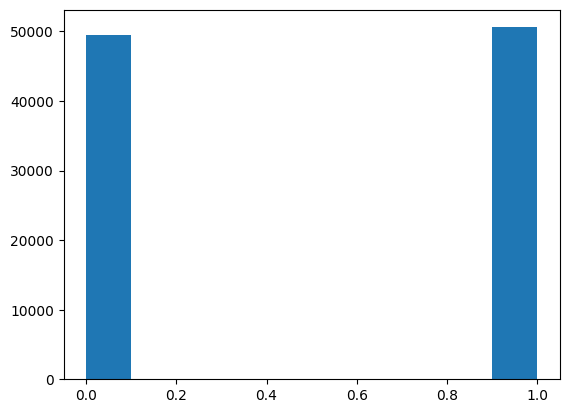

In [ ]:
plt.hist(df["ca_cervix"])
plt.show()

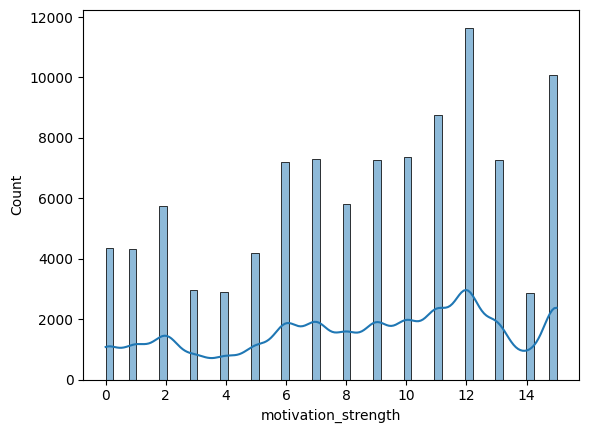

In [ ]:

sns.histplot(df['motivation_strength'], kde=True)
plt.show()

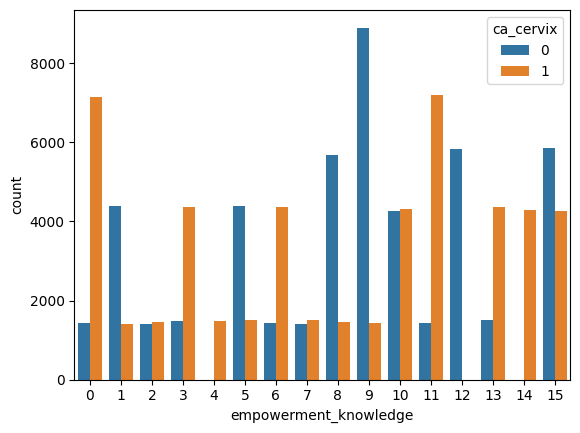

In [ ]:
sns.countplot(data=df, x='empowerment_knowledge', hue='ca_cervix')
plt.show()

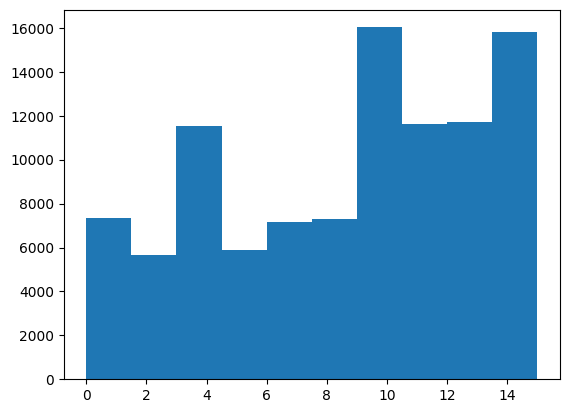

In [ ]:
plt.hist(df["socialSupport_emotionality"])
plt.show()

<Axes: xlabel='intention_commitment', ylabel='motivation_strength'>

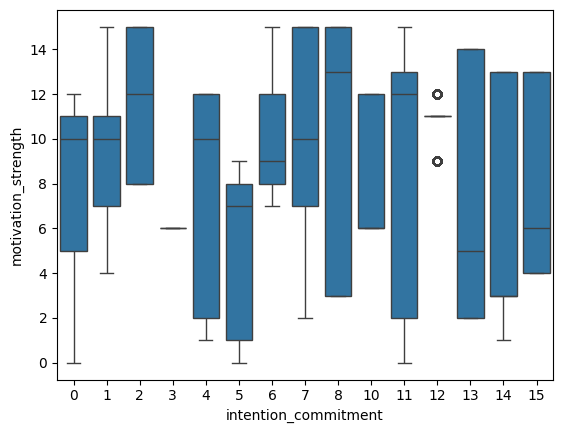

In [ ]:
sns.boxplot(x="intention_commitment", y="motivation_strength", data=df)

## **correlation**

In [ ]:
df.head()

,behavior_sexualRisk,behavior_eating,behavior_personalHygine,intention_aggregation,intention_commitment,attitude_consistency,attitude_spontaneity,norm_significantPerson,norm_fulfillment,perception_vulnerability,perception_severity,motivation_strength,motivation_willingness,socialSupport_emotionality,socialSupport_appreciation,socialSupport_instrumental,empowerment_knowledge,empowerment_abilities,empowerment_desires,ca_cervix
0,14,8,1,9,7,13,1,10,12,4,6,7,0,5,0,1,15,14,0,0
1,3,11,13,6,1,2,0,4,0,7,0,10,0,1,1,11,5,6,4,0
2,4,1,11,9,12,5,4,5,0,4,8,11,9,13,1,0,13,9,12,0
3,7,3,10,0,7,3,5,7,3,13,2,15,13,8,2,8,12,1,15,0
4,1,4,13,0,11,14,15,0,4,11,12,15,2,3,2,15,0,15,0,1


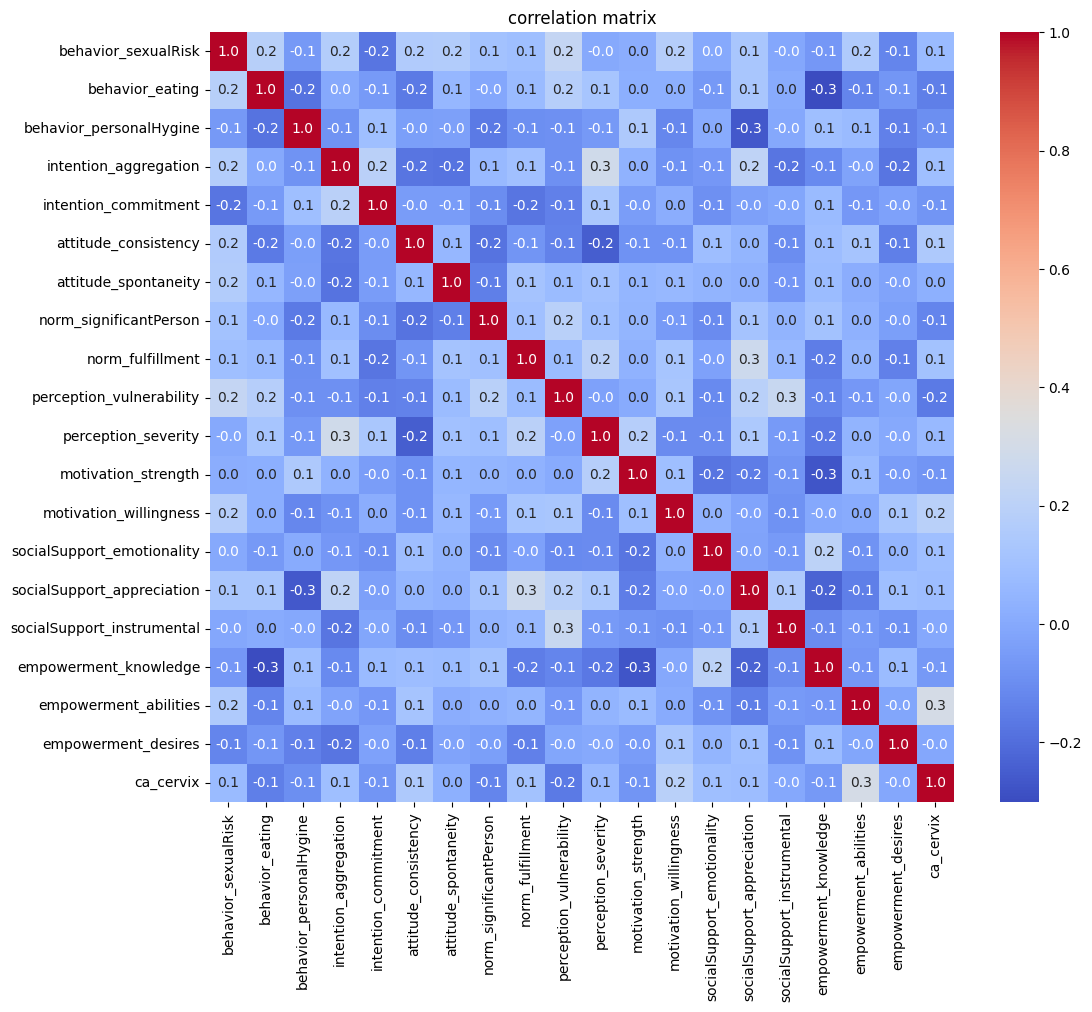

In [ ]:
plt.figure(figsize=(12,10))

corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, fmt='0.01f', cmap='coolwarm')
plt.title('correlation matrix')
plt.show()

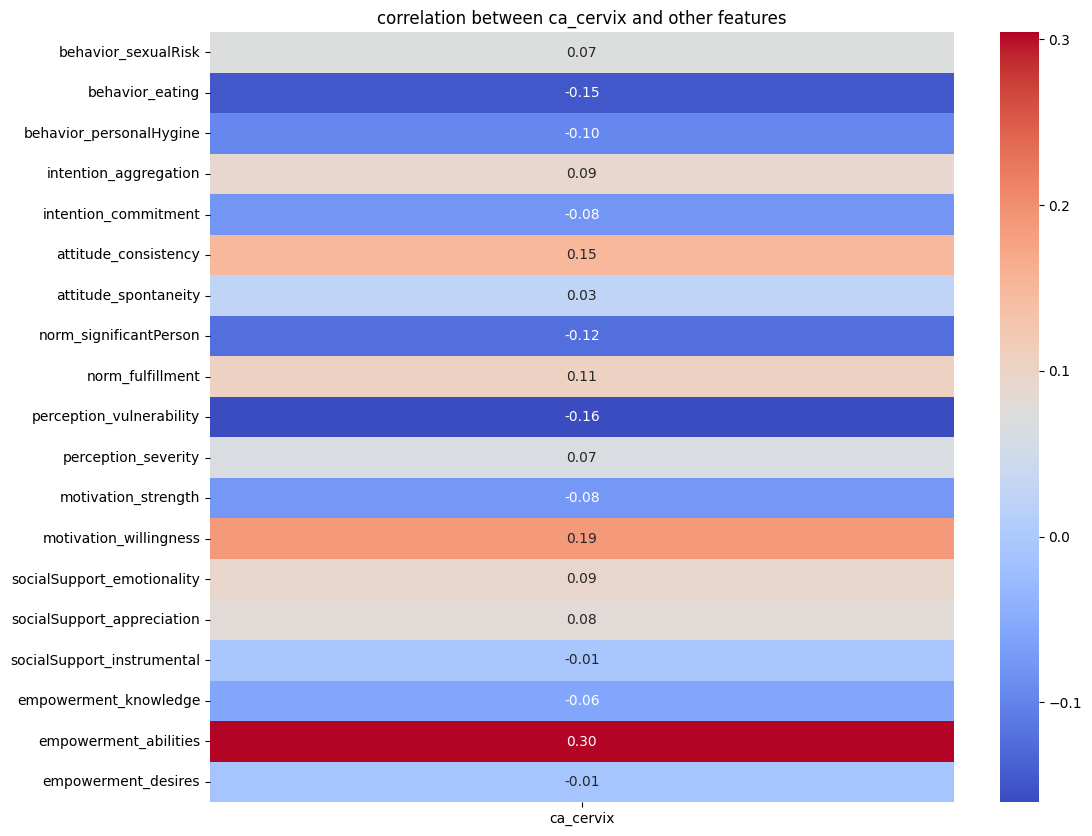

In [ ]:
plt.figure(figsize=(12,10))

ca_cervix_corr = df.corr()['ca_cervix']

ca_cervix_corr = ca_cervix_corr.drop('ca_cervix')

sns.heatmap(ca_cervix_corr.to_frame(), annot=True, fmt='0.2f', cmap='coolwarm', cbar=True, annot_kws={'size':10})

plt.title('correlation between ca_cervix and other features')
plt.show()

In [ ]:
df.drop(['behavior_sexualRisk', 'intention_aggregation', 'intention_commitment', 'attitude_spontaneity', 'perception_severity', 'motivation_strength', 'socialSupport_emotionality', 'socialSupport_appreciation',
         'socialSupport_instrumental', 'empowerment_knowledge', 'empowerment_desires'], inplace=True, axis=1)

In [ ]:
df

,behavior_eating,behavior_personalHygine,attitude_consistency,norm_significantPerson,norm_fulfillment,perception_vulnerability,motivation_willingness,empowerment_abilities,ca_cervix
0,8,1,13,10,12,4,0,14,0
1,11,13,2,4,0,7,0,6,0
2,1,11,5,5,0,4,9,9,0
3,3,10,3,7,3,13,13,1,0
4,4,13,14,0,4,11,2,15,1
...,...,...,...,...,...,...,...,...,...
99995,10,12,8,4,5,4,6,13,1
99996,2,14,10,11,12,1,2,6,0
99997,4,13,14,0,4,11,2,15,1
99998,2,5,9,13,8,4,11,13,1


## **outlier checking and removing**

<Axes: >

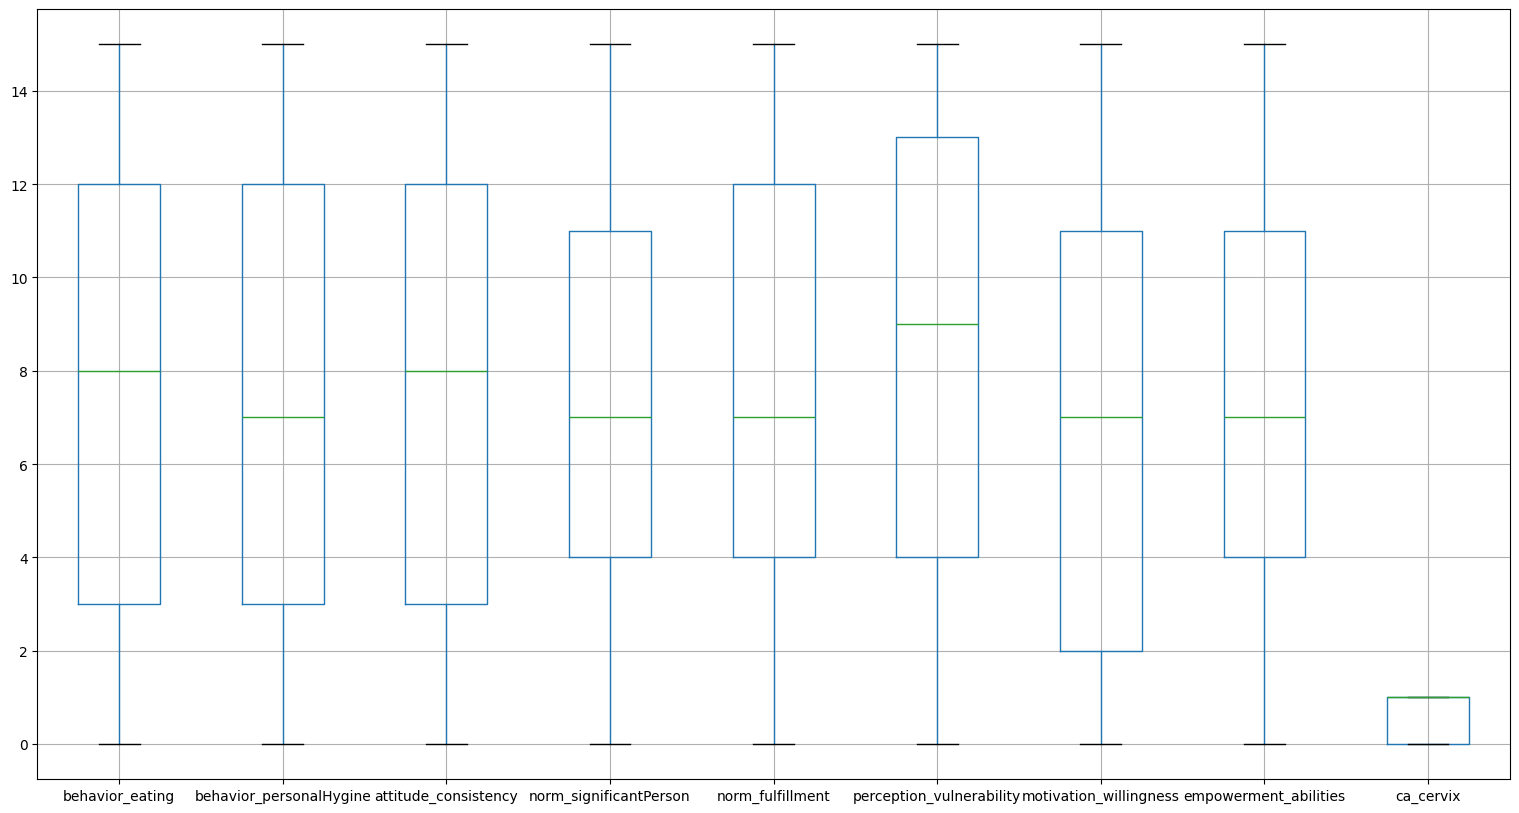

In [ ]:
plt.figure(figsize= (19,10))

df.boxplot()

## **train test split**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

x = df[['behavior_eating', 'behavior_personalHygine', 'attitude_consistency', 'norm_significantPerson', 'norm_fulfillment', 'perception_vulnerability', 'motivation_willingness', 'empowerment_abilities']]
y = df['ca_cervix']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

model = LogisticRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy: 0.2f}')

Baseline model accuracy:  0.69


## **Kfold**

In [ ]:
from sklearn.model_selection import KFold

x = df.drop("ca_cervix", axis=1)
y = df["ca_cervix"]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LogisticRegression()


best_accuracy = 0
best_fold = -1

best_x_train = None
best_y_train = None
best_x_test = None
best_y_test = None
best_y_pred = None


for fold, (train_index, test_index) in enumerate(kf.split(x), 1):
  x_train, x_test = x.iloc[train_index], x.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]

  model.fit(x_train,y_train)

  y_pred = model.predict(x_test)
  acc = accuracy_score(y_test, y_pred)
  print(f"Fold {fold} Accuracy: {acc}")


  if acc > best_accuracy:
     best_accuracy = acc
     best_fold = fold
     best_x_train = x_train
     best_y_train = y_train
     best_x_test = x_test
     best_y_test = y_test
     best_y_pred = y_pred

print(f"\n Best Fold: {best_fold} with Accuracy: {best_accuracy}")

Fold 1 Accuracy: 0.6926
Fold 2 Accuracy: 0.69345
Fold 3 Accuracy: 0.69165
Fold 4 Accuracy: 0.6952
Fold 5 Accuracy: 0.70085

 Best Fold: 5 with Accuracy: 0.70085


In [ ]:
model = LogisticRegression()
model.fit(best_x_train, best_y_train)
model.score(best_x_test, best_y_test)

0.70085

## **Decision Tree Algorithm**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(best_x_train, best_y_train)

best_y_pred = model.predict(best_x_test)

accuracy = accuracy_score(best_y_test, best_y_pred)

print(f"Baseline model accuracy: {accuracy: 0.2f}")

Baseline model accuracy:  1.00


## **Support Vector Machine**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler

In [ ]:
pipeline = Pipeline([('scaler', StandardScaler()),('model', LinearSVC(random_state=42, max_iter=5000))])

pipeline.fit(best_x_train, best_y_train)

y_pred = pipeline.predict(best_x_test)

print("Accuracy:", accuracy_score(best_y_test, best_y_pred))

Accuracy: 1.0


## **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(best_x_train, best_y_train)
best_y_pred = model.predict(best_x_test)

accuracy = accuracy_score(best_y_test, best_y_pred)

print(f"Baseline model accuracy: {accuracy: 0.2f}")

Baseline model accuracy:  1.00


## **DL**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.metrics import Accuracy

In [ ]:
model = Sequential([Dense(64, input_shape=(8,), activation='relu'),
                    Dense(32, activation='relu'),
                    Dense(1, activation='sigmoid'),
                    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'] )

In [ ]:
model.fit(best_x_train, best_y_train, epochs=10,batch_size=32)

Epoch 1/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9418 - loss: 0.1615
Epoch 2/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 1.0000 - loss: 3.3034e-04
Epoch 3/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 1.0000 - loss: 3.9224e-05
Epoch 4/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 1.0000 - loss: 7.9489e-06
Epoch 5/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 1.0000 - loss: 1.7585e-06
Epoch 6/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 1.0000 - loss: 3.7836e-07
Epoch 7/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 1.0000 - loss: 8.7154e-08
Epoch 8/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 1.0000 - loss: 2.5030e-08
Epoch 9/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 1.0000 - loss: 1.0726e-08
Epoch 10/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 1.0000 - loss: 7.9326e-09


In [ ]:
test_loss, test_acc = model.evaluate(best_x_test, best_y_test)

print(f'\nTest Accuracy: {test_acc}')

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 7.5866e-09

Test Accuracy: 1.0


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(best_x_train, best_y_train)
best_y_pred = model.predict(best_x_test)

accuracy = accuracy_score(best_y_test, best_y_pred)

print(f"Baseline model accuracy: {accuracy: 0.2f}")

Baseline model accuracy:  1.00


In [ ]:
import pickle
with open("cervicalcancer_randomforest_model.pkl", "wb") as file:
  pickle.dump(model, file)

In [ ]:
with open("/content/cervicalcancer_randomforest_model.pkl", "rb") as file:
  load_model = pickle.load(file)

In [ ]:
best_y_pred = load_model.predict(best_x_test)

accuracy = accuracy_score(best_y_test, best_y_pred)

print(f"Baseline model accuracy: {accuracy: 0.2f}")

Baseline model accuracy:  1.00


## **conclusion:**

This project aimed to predict cervical cancer (ca_cervix) using selected behavioral, social, and psychological factors such as eating behavior, personal hygiene, attitude consistency, social norms, perception of vulnerability, motivation willingness, and empowerment abilities. After preprocessing the dataset and properly splitting it into training and testing sets, multiple machine learning algorithms including Decision Tree, Support Vector Machine (SVM), and Random Forest were implemented and evaluated to identify the most effective predictive model.

Among all the models tested, the Random Forest classifier achieved the highest accuracy score of 1.0 on the evaluation dataset. The final optimized model was saved in pickle format for future deployment and real-time prediction use. This project demonstrates how ensemble learning techniques can effectively capture complex relationships in behavioral health data and highlights the potential of machine learning in supporting early detection and preventive healthcare strategies for cervical cancer.